In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
dataset_path = '/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color'

# Transforms
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load dataset
full_dataset = datasets.ImageFolder(dataset_path, transform=val_transforms)
class_names = full_dataset.classes
print(f"Total classes: {len(class_names)}")
print(f"Total images: {len(full_dataset)}")

# Recreate same split with same seed
total = len(full_dataset)
train_size = int(0.8 * total)
val_size = int(0.1 * total)
test_size = total - train_size - val_size

_, _, test_set = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

test_loader = DataLoader(
    test_set,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print(f"Test size: {len(test_set)}")
print(f"Test batches: {len(test_loader)}")

Total classes: 38
Total images: 54305
Test size: 5431
Test batches: 170


In [4]:
class PlantDiseaseModel(nn.Module):
    def __init__(self, num_classes=38):
        super().__init__()
        self.backbone = models.efficientnet_b3(
            weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1
        )
        for param in self.backbone.parameters():
            param.requires_grad = False
        for param in list(self.backbone.parameters())[-20:]:
            param.requires_grad = True

        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

In [5]:
model_path = '/kaggle/input/models/snrupendra2/plant-output/pytorch/default/1/best_model.pth'

checkpoint = torch.load(model_path, map_location=device)
print(f"Saved at epoch: {checkpoint['epoch']}")
print(f"Saved val accuracy: {checkpoint['val_acc']:.2f}%")

# Load model
eval_model = PlantDiseaseModel(num_classes=38)
eval_model.load_state_dict(checkpoint['model_state_dict'])
eval_model = eval_model.to(device)
eval_model.eval()

loaded_class_names = checkpoint['class_names']
print(f"Classes loaded: {len(loaded_class_names)}")
print("Model ready for evaluation")

Saved at epoch: 15
Saved val accuracy: 99.12%
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 194MB/s]


Classes loaded: 38
Model ready for evaluation


In [6]:
print("Running evaluation on test set...")

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(test_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = eval_model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

        if (batch_idx + 1) % 20 == 0:
            print(f"  Processed {batch_idx+1}/{len(test_loader)} batches")

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

test_acc = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")
print(f"Correct: {(all_preds == all_labels).sum()} / {len(all_labels)}")

Running evaluation on test set...
  Processed 20/170 batches
  Processed 40/170 batches
  Processed 60/170 batches
  Processed 80/170 batches
  Processed 100/170 batches
  Processed 120/170 batches
  Processed 140/170 batches
  Processed 160/170 batches

Test Accuracy: 98.97%
Correct: 5375 / 5431


In [7]:
short_names = [name.replace('___', '-').replace('_',' ') for name in loaded_class_names]

print("Classification Report:")
print("=" * 80)
print(classification_report(
    all_labels,
    all_preds,
    target_names=short_names,
    digits=3
))

Classification Report:
                                                  precision    recall  f1-score   support

                                Apple-Apple scab      1.000     0.972     0.986        72
                                 Apple-Black rot      1.000     1.000     1.000        64
                          Apple-Cedar apple rust      1.000     1.000     1.000        23
                                   Apple-healthy      0.994     1.000     0.997       169
                               Blueberry-healthy      1.000     1.000     1.000       130
          Cherry (including sour)-Powdery mildew      0.991     0.991     0.991       116
                 Cherry (including sour)-healthy      1.000     1.000     1.000        82
Corn (maize)-Cercospora leaf spot Gray leaf spot      0.891     0.911     0.901        45
                       Corn (maize)-Common rust       1.000     1.000     1.000       113
               Corn (maize)-Northern Leaf Blight      0.957     0.947     0.

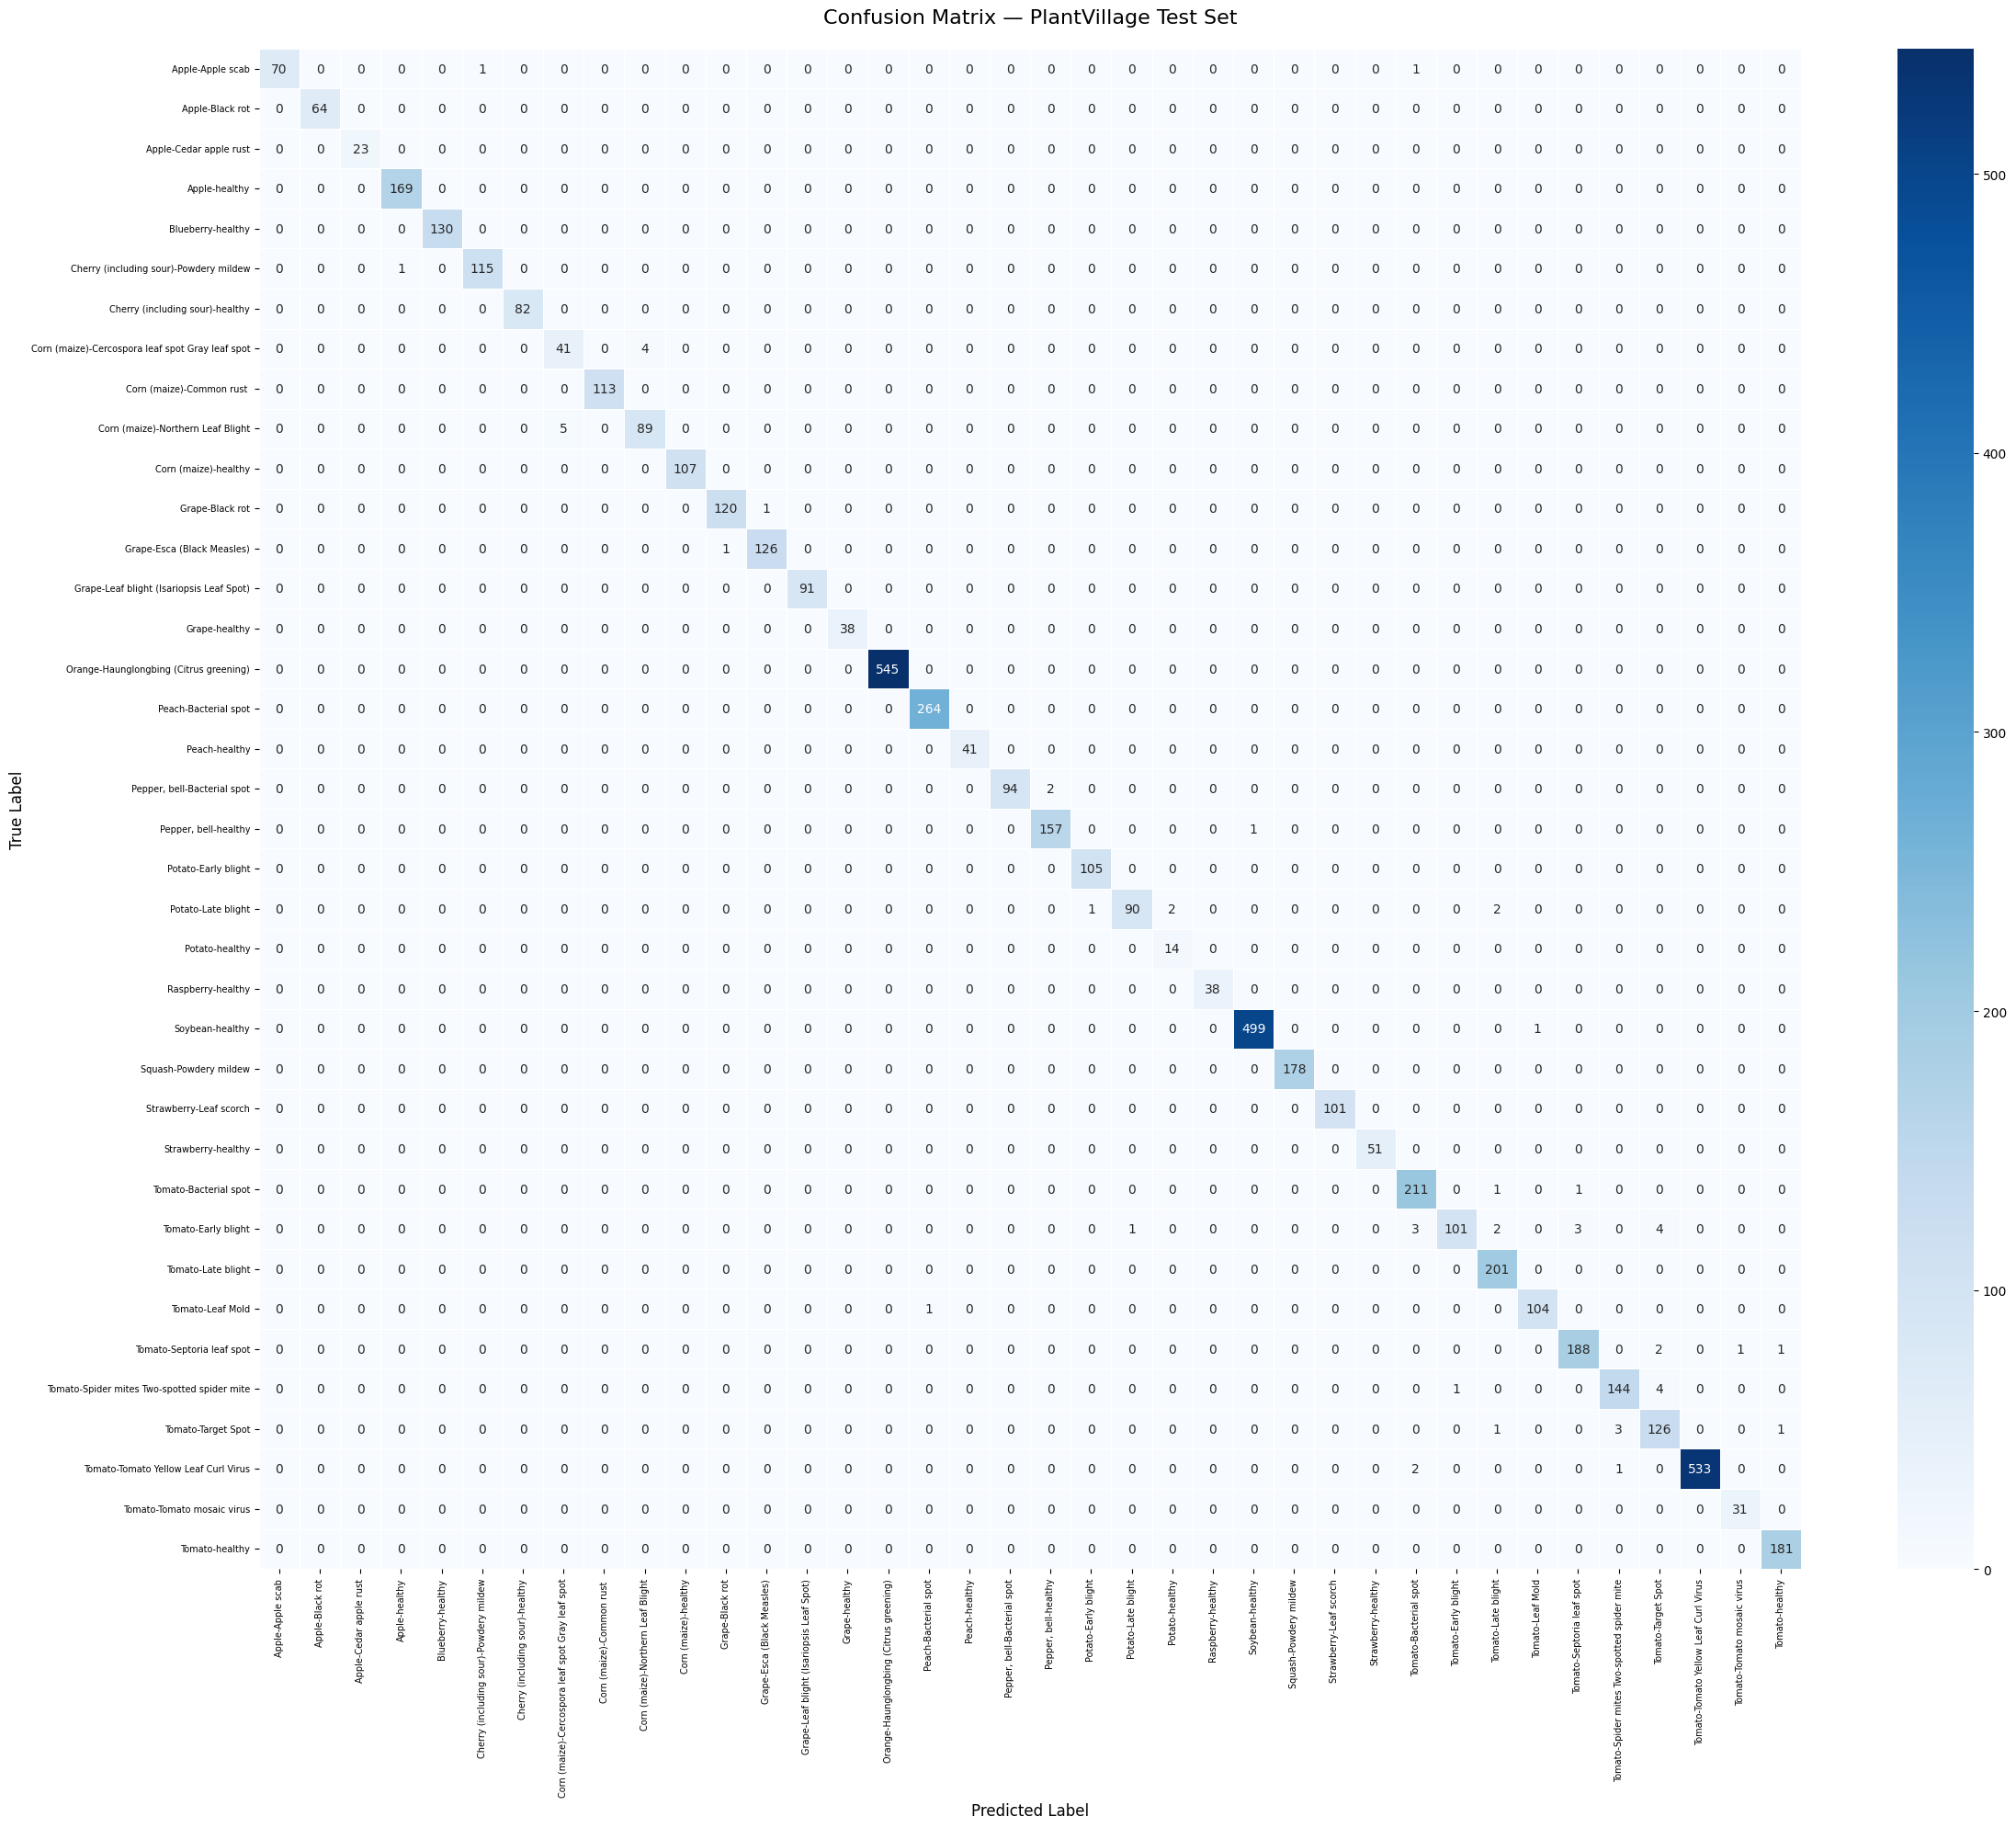

In [8]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(24, 20))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=short_names,
    yticklabels=short_names,
    cmap='Blues',
    linewidth=0.5
)
plt.title('Confusion Matrix — PlantVillage Test Set', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print("Per-Class Accuracy (sorted worst to best):")
print("-" * 55)

class_accuracies = []
for i, class_name in enumerate(loaded_class_names):
    class_mask = all_labels == i
    if class_mask.sum() > 0:
        class_acc = (all_preds[class_mask] == all_labels[class_mask]).mean() * 100
        class_count = class_mask.sum()
        class_accuracies.append((class_name, class_acc, class_count))

class_accuracies.sort(key=lambda x: x[1])

print("Bottom 10 - hardest classes:")
for name, acc, count in class_accuracies[:10]:
    short = name.replace('___', ' - ').replace('_', ' ')
    print(f"  {short:<45} {acc:6.2f}% ({count} images)")

print("\nTop 10 - easiest classes:")
for name, acc, count in class_accuracies[-10:]:
    short = name.replace('___', ' - ').replace('_', ' ')
    print(f"  {short:<45} {acc:6.2f}% ({count} images)")

Per-Class Accuracy (sorted worst to best):
-------------------------------------------------------
Bottom 10 - hardest classes:
  Tomato - Early blight                          88.60% (114 images)
  Corn (maize) - Cercospora leaf spot Gray leaf spot  91.11% (45 images)
  Corn (maize) - Northern Leaf Blight            94.68% (94 images)
  Potato - Late blight                           94.74% (95 images)
  Tomato - Target Spot                           96.18% (131 images)
  Tomato - Spider mites Two-spotted spider mite  96.64% (149 images)
  Apple - Apple scab                             97.22% (72 images)
  Pepper, bell - Bacterial spot                  97.92% (96 images)
  Tomato - Septoria leaf spot                    97.92% (192 images)
  Tomato - Leaf Mold                             99.05% (105 images)

Top 10 - easiest classes:
  Peach - healthy                               100.00% (41 images)
  Potato - Early blight                         100.00% (105 images)
  Potato - healthy

In [10]:
max_probs = all_probs.max(axis=1)
incorrect_mask = all_preds != all_labels
incorrect_indices = np.where(incorrect_mask)[0]

print(f"Total misclassifications: {incorrect_mask.sum()} / {len(all_labels)}")
print(f"Error rate: {incorrect_mask.mean() * 100.0:.2f}%")

if len(incorrect_indices) > 0:
    incorrect_probs = max_probs[incorrect_indices]
    top_incorrect = incorrect_indices[np.argsort(incorrect_probs)[-10:]]

    print("\nTop 10 most confident wrong predictions:")
    print("-" * 55)
    for idx in reversed(top_incorrect):
        true_name = loaded_class_names[all_labels[idx]].replace('___', ' - ')
        pred_name = loaded_class_names[all_preds[idx]].replace('___', ' - ')
        confidence = max_probs[idx] * 100
        print(f"  True: {true_name}")
        print(f"  Pred: {pred_name} ({confidence:.1f}% confidence)")
        print()

Total misclassifications: 56 / 5431
Error rate: 1.03%

Top 10 most confident wrong predictions:
-------------------------------------------------------
  True: Corn_(maize) - Northern_Leaf_Blight
  Pred: Corn_(maize) - Cercospora_leaf_spot Gray_leaf_spot (95.5% confidence)

  True: Corn_(maize) - Northern_Leaf_Blight
  Pred: Corn_(maize) - Cercospora_leaf_spot Gray_leaf_spot (94.0% confidence)

  True: Corn_(maize) - Cercospora_leaf_spot Gray_leaf_spot
  Pred: Corn_(maize) - Northern_Leaf_Blight (92.7% confidence)

  True: Grape - Esca_(Black_Measles)
  Pred: Grape - Black_rot (91.5% confidence)

  True: Tomato - Spider_mites Two-spotted_spider_mite
  Pred: Tomato - Target_Spot (91.0% confidence)

  True: Tomato - Bacterial_spot
  Pred: Tomato - Late_blight (90.3% confidence)

  True: Tomato - Target_Spot
  Pred: Tomato - Spider_mites Two-spotted_spider_mite (88.2% confidence)

  True: Tomato - Early_blight
  Pred: Tomato - Target_Spot (87.9% confidence)

  True: Cherry_(including_sour

## Grad-CAM

In [11]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from torchvision import transforms
import os

In [17]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        # Register hooks on target layer
        target_layer.register_forward_hook(self._save_activations)
        target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, input, output):
        # Called during forward pass — save feature maps
        self.activations = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        # Called during backward pass — save gradients
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()

        # Forward pass
        output = self.model(input_tensor)

        # If no class specified, use predicted class
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        # Zero all gradients
        self.model.zero_grad()

        # Backward pass for target class only
        output[0, class_idx].backward()

        # Global average pool gradients — one weight per channel
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        # Weighted combination of feature maps
        cam = (weights * self.activations).sum(dim=1, keepdim=True)

        # ReLU — keep only positive contributions
        cam = F.relu(cam)

        # Normalize to 0-1
        cam = cam.squeeze().cpu().numpy()
        cam_min = cam.min()
        cam_max = cam.max()
        if cam_max - cam_min > 1e-8:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = np.zeros_like(cam)

        return cam, class_idx


def apply_heatmap(original_image_np, cam, alpha=0.4):
    """
    Overlay Grad-CAM heatmap on original image.
    original_image_np: numpy array (H, W, 3) uint8 0-255
    cam: numpy array (h, w) float 0-1
    """
    # Resize CAM to image size
    cam_resized = cv2.resize(cam, (224, 224))

    # Convert to colormap (jet: blue=low, red=high)
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam_resized),
        cv2.COLORMAP_JET
    )
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Blend heatmap with original image
    overlay = (alpha * heatmap + (1 - alpha) * original_image_np)
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    return overlay, heatmap

In [18]:
# The target layer is the last convolutional block in EfficientNet-B3
# backbone.features[-1] is the last stage before global average pooling
target_layer = eval_model.backbone.features[-1]
print(f"Target layer: {type(target_layer).__name__}")
print(f"Target layer details: {target_layer}")

gradcam = GradCAM(eval_model, target_layer)
print("GradCAM initialized successfully")

Target layer: Conv2dNormActivation
Target layer details: Conv2dNormActivation(
  (0): Conv2d(384, 1536, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1536, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): SiLU(inplace=True)
)
GradCAM initialized successfully


In [19]:
def preprocess_image(image_path):
    """Load and preprocess a single image for inference."""
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    img = Image.open(image_path).convert('RGB')
    img_resized = img.resize((224, 224))
    original_np = np.array(img_resized)

    tensor = transform(img).unsqueeze(0)
    return tensor, original_np


def visualize_gradcam(image_path, gradcam, class_names, true_label=None):
    """
    Run Grad-CAM on a single image and visualize results.
    """
    # Preprocess
    img_tensor, original_np = preprocess_image(image_path)
    img_tensor = img_tensor.to(device)

    # Generate Grad-CAM
    cam, pred_idx = gradcam.generate(img_tensor)
    pred_class = class_names[pred_idx]

    # Get confidence
    with torch.no_grad():
        output = eval_model(img_tensor)
        probs = torch.softmax(output, dim=1)[0]
        confidence = probs[pred_idx].item() * 100

    # Apply heatmap
    overlay, heatmap = apply_heatmap(original_np, cam)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(original_np)
    axes[0].set_title('Original Image', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(heatmap)
    axes[1].set_title('Grad-CAM Heatmap', fontsize=12)
    axes[1].axis('off')

    axes[2].imshow(overlay)
    pred_short = pred_class.replace('___', '\n').replace('_', ' ')
    axes[2].set_title(
        f'Overlay\nPred: {pred_short}\nConf: {confidence:.1f}%',
        fontsize=10
    )
    axes[2].axis('off')

    if true_label:
        true_short = true_label.replace('___', ' ').replace('_', ' ')
        correct = "✓" if pred_class == true_label else "✗"
        fig.suptitle(f'True: {true_short}  {correct}', fontsize=12, y=1.02)

    plt.tight_layout()
    plt.show()

    return pred_class, confidence

In [20]:
dataset_path = '/kaggle/input/plantvillage-dataset/color'

# Test on several classes — including easy and hard ones
test_cases = [
    'Tomato___Early_blight',        # hardest class
    'Tomato___Target_Spot',         # confused with Early Blight
    'Corn_(maize)___Northern_Leaf_Blight',   # confused with Cercospora
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
    'Apple___Apple_scab',
    'Potato___Late_blight',
    'Tomato___healthy',             # easiest classes
    'Squash___Powdery_mildew'
]

print("Running Grad-CAM visualization...")
print("=" * 60)

for class_name in test_cases:
    class_path = os.path.join(dataset_path, class_name)

    if not os.path.exists(class_path):
        print(f"Skipping {class_name} — path not found")
        continue

    # Pick first image from this class
    img_files = os.listdir(class_path)
    if len(img_files) == 0:
        continue

    img_path = os.path.join(class_path, img_files[0])

    print(f"\nClass: {class_name.replace('___', ' - ')}")
    pred_class, confidence = visualize_gradcam(
        img_path,
        gradcam,
        loaded_class_names,
        true_label=class_name
    )
    print(f"Predicted: {pred_class.replace('___', ' - ')} ({confidence:.1f}%)")

Running Grad-CAM visualization...
Skipping Tomato___Early_blight — path not found
Skipping Tomato___Target_Spot — path not found
Skipping Corn_(maize)___Northern_Leaf_Blight — path not found
Skipping Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot — path not found
Skipping Apple___Apple_scab — path not found
Skipping Potato___Late_blight — path not found
Skipping Tomato___healthy — path not found
Skipping Squash___Powdery_mildew — path not found


In [21]:
def compare_confused_pair(class1, class2, gradcam, class_names, dataset_path):
    """
    Show Grad-CAM for two visually similar classes side by side.
    Helps understand why the model confuses them.
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    for row, class_name in enumerate([class1, class2]):
        class_path = os.path.join(dataset_path, class_name)
        img_files = os.listdir(class_path)
        img_path = os.path.join(class_path, img_files[2])

        img_tensor, original_np = preprocess_image(img_path)
        img_tensor = img_tensor.to(device)

        cam, pred_idx = gradcam.generate(img_tensor)
        pred_class = class_names[pred_idx]

        with torch.no_grad():
            output = eval_model(img_tensor)
            probs = torch.softmax(output, dim=1)[0]
            confidence = probs[pred_idx].item() * 100

        overlay, heatmap = apply_heatmap(original_np, cam)

        axes[row][0].imshow(original_np)
        axes[row][0].set_title(
            f'True: {class_name.replace("___", " - ").replace("_", " ")}',
            fontsize=9
        )
        axes[row][0].axis('off')

        axes[row][1].imshow(heatmap)
        axes[row][1].set_title('Grad-CAM', fontsize=9)
        axes[row][1].axis('off')

        axes[row][2].imshow(overlay)
        correct = "✓" if pred_class == class_name else "✗"
        axes[row][2].set_title(
            f'Pred: {pred_class.replace("___", " - ").replace("_", " ")}\n'
            f'Conf: {confidence:.1f}% {correct}',
            fontsize=9
        )
        axes[row][2].axis('off')

    plt.suptitle(
        'Confused Pair Comparison',
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    plt.show()

In [25]:
import os

dataset_path = '/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color'
all_classes = os.listdir(dataset_path)

# Find all corn classes
corn_classes = [c for c in all_classes if 'Corn' in c or 'corn' in c]
print("Corn classes found:")
for c in corn_classes:
    print(f"  '{c}'")

# Find all tomato classes
tomato_classes = [c for c in all_classes if 'Tomato' in c or 'tomato' in c]
print("\nTomato classes found:")
for c in tomato_classes:
    print(f"  '{c}'")

Corn classes found:
  'Corn_(maize)___Northern_Leaf_Blight'
  'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot'
  'Corn_(maize)___Common_rust_'
  'Corn_(maize)___healthy'

Tomato classes found:
  'Tomato___Late_blight'
  'Tomato___healthy'
  'Tomato___Early_blight'
  'Tomato___Septoria_leaf_spot'
  'Tomato___Tomato_Yellow_Leaf_Curl_Virus'
  'Tomato___Bacterial_spot'
  'Tomato___Target_Spot'
  'Tomato___Tomato_mosaic_virus'
  'Tomato___Leaf_Mold'
  'Tomato___Spider_mites Two-spotted_spider_mite'


Comparing most confused pairs:

1. Corn Northern Leaf Blight vs Cercospora:


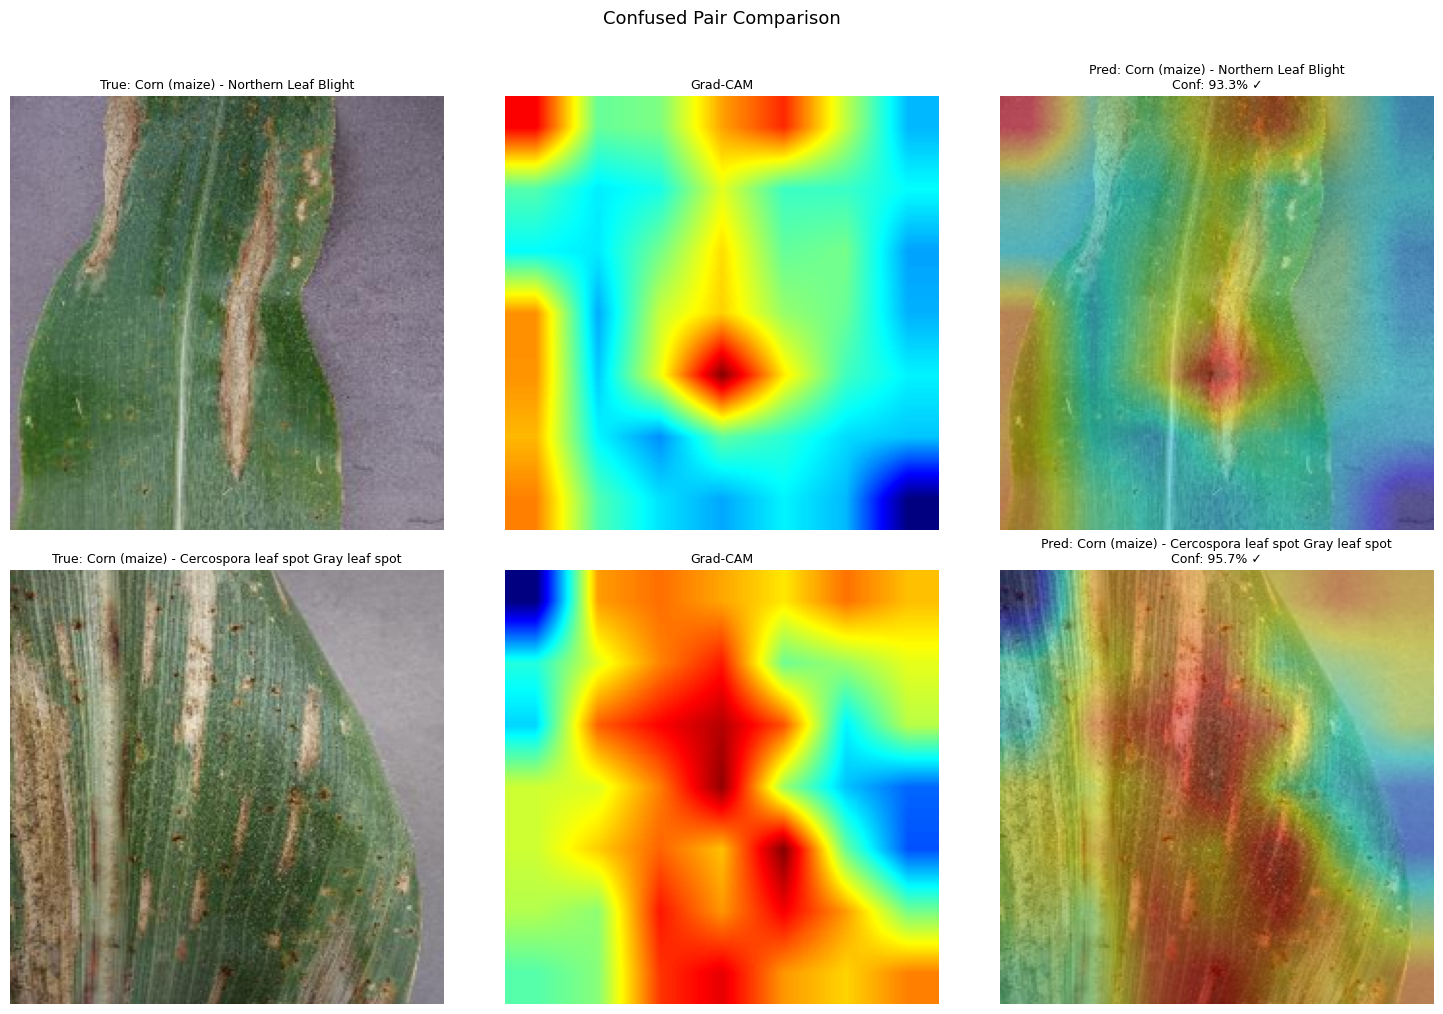


2. Tomato Early Blight vs Target Spot:


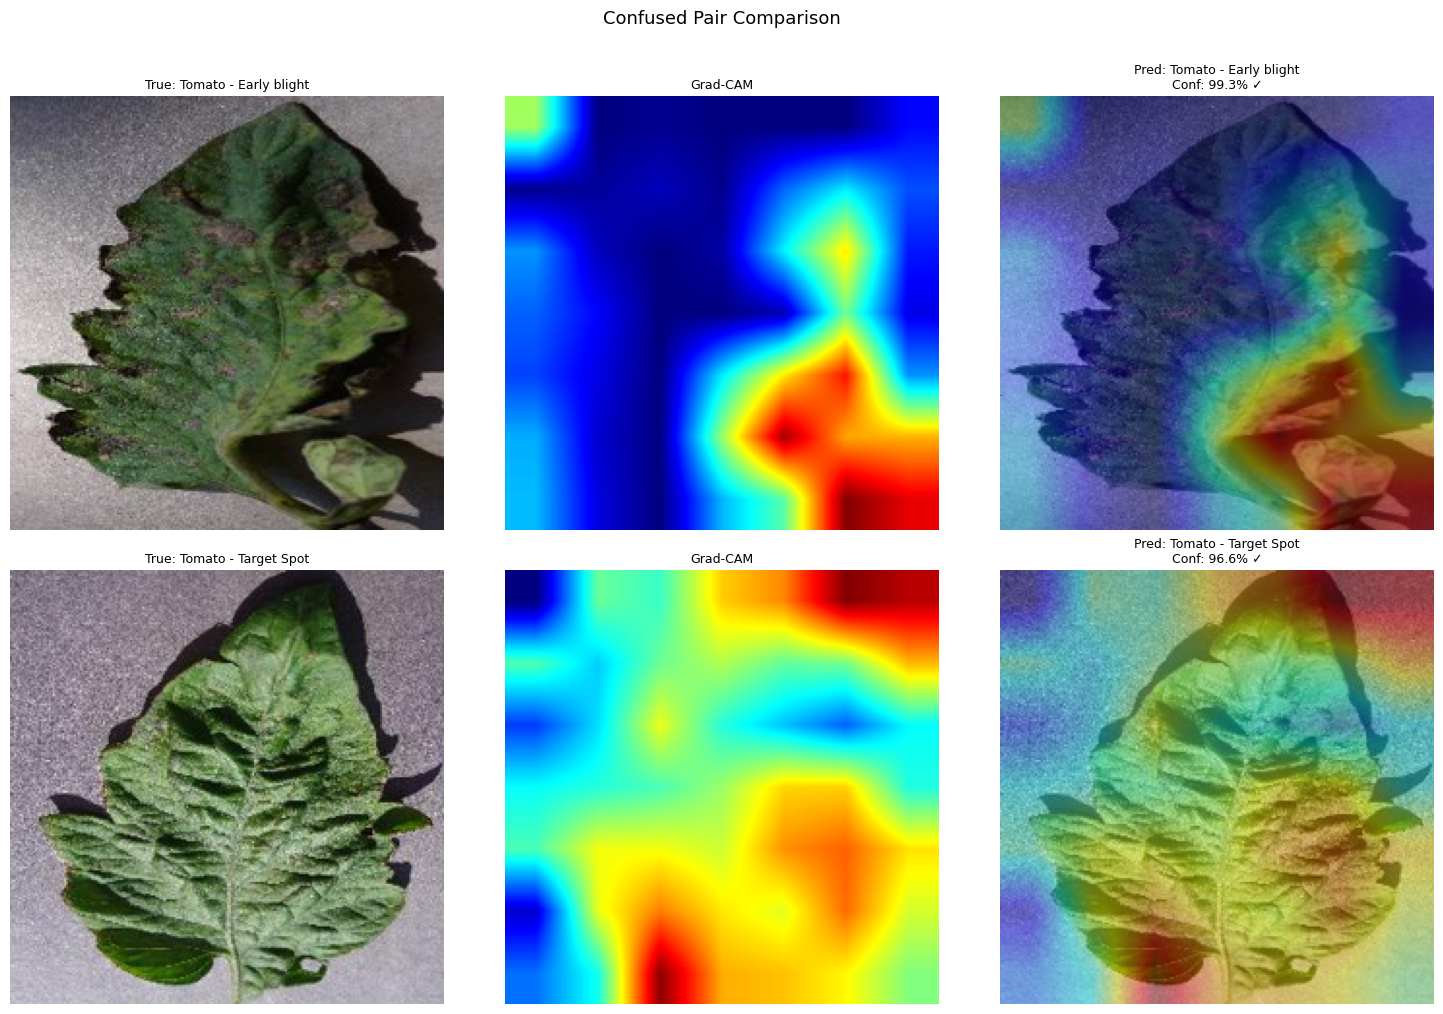

In [26]:
# Compare the most confused pairs from evaluation
print("Comparing most confused pairs:")
print("\n1. Corn Northern Leaf Blight vs Cercospora:")
compare_confused_pair(
    'Corn_(maize)___Northern_Leaf_Blight',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
    gradcam,
    loaded_class_names,
    dataset_path
)

print("\n2. Tomato Early Blight vs Target Spot:")
compare_confused_pair(
    'Tomato___Early_blight',
    'Tomato___Target_Spot',
    gradcam,
    loaded_class_names,
    dataset_path
)